<a href="https://colab.research.google.com/github/LuanaGoncalves177/Linguagem_Python_Colab/blob/main/Python_Desafio_de_Regress%C3%A3o_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Desafio de Regressão Linear em Python

1. Importar o arquivo slr12.csv;
2. criar um modelo de regressão linear para prever o investientos inicial de uma franquia a partir de uma taxa anual cobrada pelo franqueador;
3. Variáveis:
  FraAnula: Taxa Anual
  CusInic: Investimento Inicial

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
# warming - Aviso
from yellowbrick.regressor import ResidualsPlot

# Carregar da base de dados e exclusão da primeira linha
base = pd.read_csv('slr12.csv', sep=';')
base.shape

(36, 2)

In [ ]:
base.head()

,FrqAnual,CusInic
0,1000,1050
1,1125,1150
2,1087,1213
3,1070,1275
4,1100,1300


In [ ]:
# Definição das variáveis X e Y
# X CusInic -  variável independente
# Y FraqAnual - variável dependente

x = base.iloc[:,1].values
y = base.iloc[:,0].values
x

array([1050, 1150, 1213, 1275, 1300, 1300, 1400, 1400, 1250, 1830, 1350,
       1450, 1300, 1300, 1275, 1375, 1285, 1400, 1400, 1285, 1275, 1135,
       1250, 1275, 1150, 1250, 1275, 1225, 1280, 1300, 1250, 1175, 1300,
       1250, 1300, 1200])

In [ ]:
# Correlação das variáveis valor entre 1 (forte) e -1 (fraco)
correlacao = np.corrcoef(x,y)
correlacao

array([[1.        , 0.47700725],
       [0.47700725, 1.        ]])

In [ ]:
# Formato de Matriz com 1 coluna a mais
x = x.reshape( -1, 1)

# Criação do modelo de treinamento
modelo = LinearRegression()
modelo.fit(x,y)

LinearRegression()

In [ ]:
#Visualização dos coeficientes a linha de melhor ajustes toca o eixo x
modelo.intercept_

np.float64(347.5467344612957)

In [ ]:
#inclinação - O crescimento da variável dependente a independete
modelo.coef_

array([0.60975768])

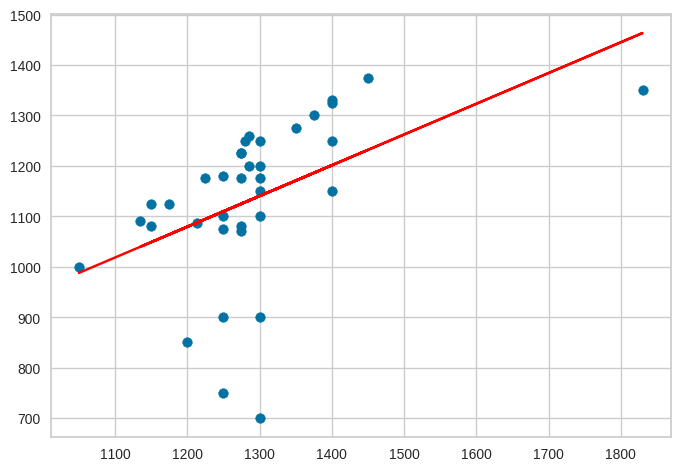

In [ ]:
#Gerar o gráfico com os pontos reais e as previsões
plt.scatter(x,y)
plt.plot(x, modelo.predict(x), color='red')

In [ ]:
# Previsão
# intercepção + inclinação * Taxa anual
# Qual o valor inicial para o investimento de 500 reais?

modelo.intercept_ + modelo.coef_ * 500

array([652.42557563])

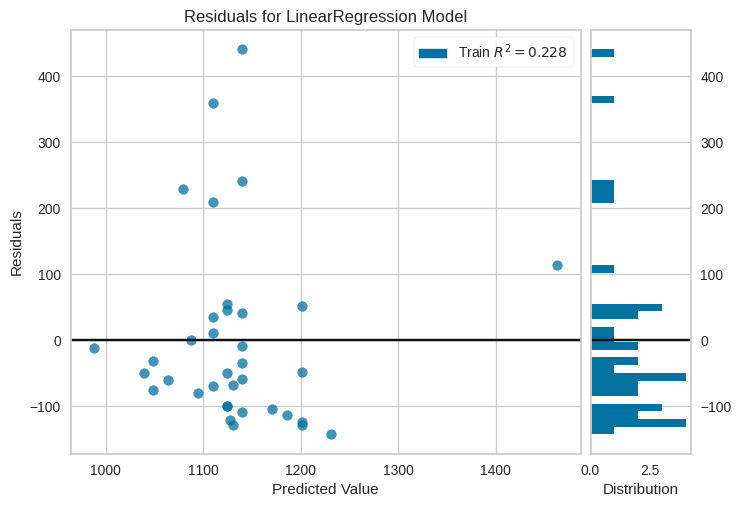

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [ ]:
# Visualização de Resíduais - Residuals

visualizador = ResidualsPlot(modelo)
visualizador.fit(x,y)
visualizador.poof()